# Projeto de Ciência de Dados - Bitcoin Prices
**Autor:** Kauan da Costa Barros  
**Dataset:** Preços Históricos e Projeções de Bitcoin (2010 - 2026)

---
## 1ª Etapa 
## 1. Introdução e Objetivo
Este notebook apresenta o processo de limpeza e tratamento de dados de uma série temporal de preços do Bitcoin. O objetivo é preparar os dados para tarefas subsequentes de **Regressão** (predição de preço) e **Classificação** (categoria de preço).

### 2. Importação de Bibliotecas e Carga dos Dados
Nesta etapa, carregamos o `pandas` para manipulação de DataFrames e o `numpy` para operações matemáticas vetorizadas.

In [8]:
import pandas as pd
import numpy as np

try:
    df = pd.read_csv('bitcoin.csv')
    print("Dataset carregado com sucesso!")
except FileNotFoundError:
    print("Arquivo não encontrado. Verifique o caminho.")

Dataset carregado com sucesso!


### 3. Algoritmo de Limpeza e Ordenação Cronológica
O processo de limpeza segue as seguintes regras de negócio:
1. **Padronização Temporal**: Conversão para o formato `datetime`.
2. **Ordenação**: Organização cronológica (do mais antigo ao mais recente).
3. **Unicidade**: Remoção de possíveis duplicatas por data.
4. **Integridade Lógica**: Garantir que a máxima (`High`) não seja inferior aos outros preços do dia usando **NumPy**.
5. **Continuidade**: Preenchimento de lacunas via interpolação linear.

In [9]:

df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values(by='Date').reset_index(drop=True)

df = df.drop_duplicates(subset=['Date'], keep='first')

df['High'] = np.maximum(df['High'], df[['Open', 'Low', 'Close']].max(axis=1))
df['Low'] = np.minimum(df['Low'], df[['Open', 'High', 'Close']].min(axis=1))


cols_num = ['Open', 'High', 'Low', 'Close', 'Volume']
df[cols_num] = df[cols_num].interpolate(method='linear')

print("Processamento de limpeza e ordenação concluído.")

Processamento de limpeza e ordenação concluído.


### 4. Verificação Final do Dataset
Abaixo, verificamos se a série está estritamente crescente no tempo e se não restaram valores nulos

In [10]:

esta_ordenado = df['Date'].is_monotonic_increasing
total_nulos = df.isnull().sum().sum()

print(f"A série está ordenada? {esta_ordenado}")
print(f"Total de valores nulos: {total_nulos}")


df.head()

A série está ordenada? True
Total de valores nulos: 0


,Date,Open,High,Low,Close,Volume,PriceCategory
0,2010-01-01,0.3,0.303428,0.295510,0.3,715.8,Low
1,2010-01-02,0.3,0.304377,0.299459,0.3,2028.3,Low
2,2010-01-03,0.3,0.303736,0.295858,0.3,273.0,Low
3,2010-01-04,0.3,0.303406,0.298489,0.3,1452.0,Low
4,2010-01-05,0.3,0.302715,0.296330,0.3,1002.6,Low


### 5. Exportação dos Dados Tratados
Após concluir a limpeza, ordenação e verificação de integridade, exportamos o DataFrame resultante para um novo arquivo CSV.

In [11]:

df.to_csv('bitcoin_limpo_ordenado.csv', index=False)

print("Arquivo salvo com sucesso no diretório do Jupyter!")

Arquivo salvo com sucesso no diretório do Jupyter!


# Atividade 2 - Redução de Dimensionalidade (PCA) e Correlação

Nesta fase do projeto, exploramos a relação entre as variáveis e aplicamos técnicas para reduzir a complexidade do dataset, mantendo a maior parte da informação original.


## 2.1 Matriz de Correlação de Pearson
Para entender como cada variável influencia o preço e a categoria final, transformamos a `PriceCategory` em dados numéricos e geramos o mapa de calor (Heatmap).

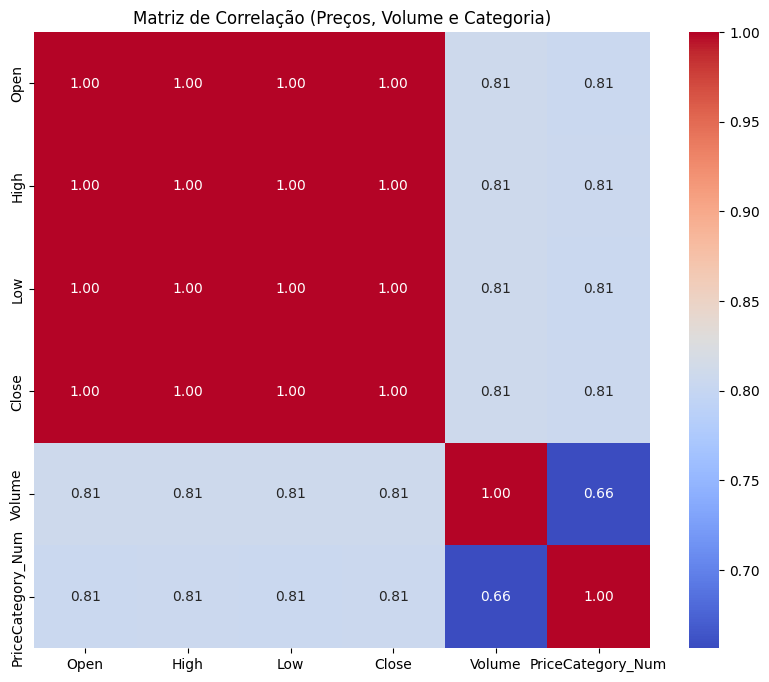

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

mapeamento = {'Low': 0, 'Medium': 1, 'High': 2}
df['PriceCategory_Num'] = df['PriceCategory'].map(mapeamento)


colunas_analise = ['Open', 'High', 'Low', 'Close', 'Volume', 'PriceCategory_Num']
matriz_corr = df[colunas_analise].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_corr, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    square=True
)

plt.title('Matriz de Correlação (Preços, Volume e Categoria)')
plt.show()